### Computing max average reward rates theoretically

Given an agent with a policy to gather $(k_1, \, k_2, \,k_3, \,...)$ rewards from an environment in which the reward function is

$$
    p(r=1 | R) = a e^{-R/\tau},
$$

where R is the sum of rewards within a patch, we would like to compute the expected return of the agent for a set of $\left(\tau_1, \tau_2, \tau_3\right)$ and a fixed $a$.

The expected reward for an environment with a single patch with reward curve parametrized by $\tau$ when the agent will gather $k$ rewards is

$$
    \mathbb{E}[r|k, \, \tau] = \frac{k}{T_{\rm intersite} + n(k, \, \tau) (T_{\rm harvest} + T_{\rm intersite}) + T_{\rm leave} + T_{\rm interpatch}},
$$

where $n(k, \, \tau)$ is the expected number of stops required to harvest $k$ rewards.

In an environment with multiple patch types and a policy of stopping $n_i$ times for each, this becomes

$$
    \mathbb{E}[r|k, \, \tau] = \frac{\sum_i k_i}{ \sum_i T_{\rm intersite} + n(k_i, \, \tau_i) (T_{\rm harvest} + T_{\rm intersite}) + T_{\rm leave} + T_{\rm interpatch}},
$$

We can first compute the probability of stopping n' times given the agent must collect k rewards and currently has collected R rewards,

$$
    p(n = n'| k, R),
$$

which obeys the recurrence relation

$$
    p(n = n'| k, R) = p(r=1| R) \, p(n = n'- 1| k-1, R+1) + p(r=0| R) \, p(n = n'- 1| k, R).
$$

We also know that if $k > n'$, then the associated probability is zero. If $k = 0$ and $n' > 0$, then the probability is also zero.

Once we have computed these probabilities, then

$$
    n(k, \, \tau) = \sum_{n'=k}^{\infty} p(n = n'| k, R) \, n'.
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random

import os, sys
sys.path.insert(0, os.path.abspath('../..'))

from theory_tools import (
    rewarded_given_i_rewards,
    unrewarded_given_i_rewards,
    p_k_consecutive_rewarded_sites_given_i_rewards,
    p_k_additional_rewards_in_n_sites_given_i_rewards,
    expected_stops_given_tau_and_k_rewards,
    expected_reward_rate_for_env_and_policy,
    sample_truncated_exp,
    find_max_policy_for_env,
)

(0.0, 100.0)

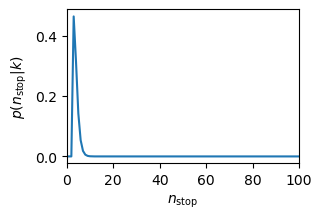

In [52]:
exp_stops, probs = expected_stops_given_tau_and_k_rewards(k=3, a=0.8, tau=30)

fig, axs = plt.subplots(1, 1, figsize=(3, 2))
axs.plot(np.arange(len(probs)), probs)
axs.set_ylabel(r'$p(n_{\rm stop} | k)$')
axs.set_xlabel(r'$n_{\rm stop} $')
axs.set_xlim(0, 100)

7.710321476816362


(0.0, 30.0)

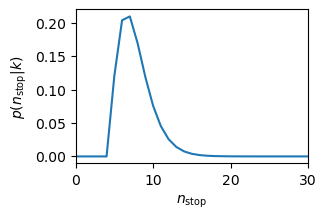

In [53]:
exp_stops, probs = expected_stops_given_tau_and_k_rewards(k=5, a=0.8, tau=10)
print(exp_stops)

fig, axs = plt.subplots(1, 1, figsize=(3, 2))
axs.plot(np.arange(len(probs)), probs)
axs.set_ylabel(r'$p(n_{\rm stop} | k)$')
axs.set_xlabel(r'$n_{\rm stop} $')
axs.set_xlim(0, 30)

20.002524290594216


(0.0, 30.0)

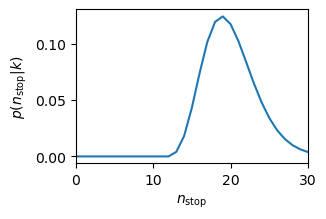

In [54]:
exp_stops, probs = expected_stops_given_tau_and_k_rewards(k=13, a=0.8, tau=30)
print(exp_stops)

fig, axs = plt.subplots(1, 1, figsize=(3, 2))
axs.plot(np.arange(len(probs)), probs)
axs.set_ylabel(r'$p(n_{\rm stop} | k)$')
axs.set_xlabel(r'$n_{\rm stop} $')
axs.set_xlim(0, 30)

Given the agent must stop to collect $k$ rewards, here is an example of the probability dist. of stopping exactly $n$ times.

## Optimal policy for varying decay, no probability offset

What is the theoretical maximum for the patch foraging task when

$$
    a_2 = a_3 = 0.8 \
$$
$$
    a_1 = 0 \
$$
$$
    \tau_2 = 10 \
$$
$$
    \tau_3 = 30
$$

In [5]:
taus = [1e-8, 10., 30.]
amps = [0.8, 0.8, 0.8]

max_policy = None
max_rate = 0
for k_2 in range(15):
    for k_3 in range(15):
        policy_rate = expected_reward_rate_for_env_and_policy(
            taus=taus,
            amps=amps,
            k_rewards_by_tau=[0, k_2, k_3],
            d_site_stop=7,
            d_site_run=3,
            d_intersite=2.15,
            interpatch=5.5,
        )
        if policy_rate > max_rate:
            max_rate = policy_rate
            max_policy = (k_2, k_3)

print('Max policy', max_policy)
print('Max rate', max_rate)
print('Leave rates', [rewarded_given_i_rewards(i-1, 0.8, tau) for (i, tau) in zip(max_policy, taus[1:])])

Max policy (4, 10)
Max rate 0.06394698026832753
Leave rates [0.5926545765453743, 0.5926545765453743]


Model predicts a max reward rate of ~0.0725, which roughly agrees with the best performance simulated agents achieve.

What if intersite distribution, which is usually a truncated exponential, is flipped?

In [24]:
max_policy = None
max_rate = 0
for k_2 in range(15):
    for k_3 in range(15):
        policy_rate = expected_reward_rate_for_env_and_policy(
            taus=[1e-8, 10, 30],
            amps=[1e-8, 0.8, 0.8],
            k_rewards_by_tau=[0, k_2, k_3],
            d_site_stop=6,
            d_site_run=3,
            d_intersite=6 - 2.15, # consider flipped distribution mean
            interpatch=5.5,
        )
        if policy_rate > max_rate:
            max_rate = policy_rate
            max_policy = (k_2, k_3)

print('Max policy', max_policy)
print('Max rate', max_rate)

Max policy (4, 10)
Max rate 0.058740612415832574


## Calculating mean intersite, interpatch

#### Computing the average time spent running through intersite and interpatch intervals drawn from truncated exponential distributions

In [4]:
interreward_len_bounds = np.array([1.0, 6.0])
interreward_len_decay_rate = 0.8
interpatch_len_bounds = np.array([1.0, 12.0])
interpatch_len_decay_rate = 0.1

In [ ]:
key = random.PRNGKey(51)
keys = random.split(key, 10000)
samples = jax.vmap(sample_truncated_exp, in_axes=(0, None, None))(keys, interreward_len_bounds, interreward_len_decay_rate)
mean_interward = jnp.mean(samples)
print('Mean interreward site distance:', mean_interward)

In [44]:
key = random.PRNGKey(101)
key, subkey = random.split(key)
keys = random.split(subkey, 10000)
samples = jax.vmap(sample_truncated_exp, in_axes=(0, None, None))(keys, interpatch_len_bounds, interpatch_len_decay_rate)
mean_interpatch = jnp.mean(samples)
print('Mean interpatch distance:', mean_interpatch)

Mean interpatch distance: 5.5706096


## What is the optimal reward rate for a series of environments where the reward parameters are drawn from a uniform distribution?

In [13]:
rates = np.zeros((50))
for i in range(50):
    taus = np.random.rand(3) * 50 + 1e-8 # draw taus independently from uniform distribution
    amps = np.ones((3)) * 0.8
    rate, policy = find_max_policy_for_env(taus, amps) # find max reward rate and policy for environment
    rates[i] = rate
    print(taus)
    print(policy)
    print(rate)
np.mean(rates)

[41.97589186  5.07452273 10.07960175]
(9, 2, 3)
0.07597427008989532
[49.5435157   9.51073837 37.51975787]
(9, 2, 8)
0.07979938687285094
[48.63925327 24.99642275 21.19844131]
(9, 5, 5)
0.07966882584277786
[45.37445669  2.71627788 45.069706  ]
(9, 1, 9)
0.07973965003110742
[16.87443427 39.59956208 41.71921206]
(4, 8, 9)
0.07995554495610867
[36.55680707 21.18387683  3.77942414]
(9, 5, 1)
0.07662856149802955
[34.12484313 43.66360955 35.64388679]
(7, 8, 7)
0.08089579691084799



KeyboardInterrupt



## Fixed decay, varying offset policy

In [8]:
rate, policy = find_max_policy_for_env([20, 20, 20], [0, 0.6, 0.8])
print(rate)
print(policy)

0.06339160125502766
(0, 3, 9)


In [29]:
rates = np.zeros((100))
for i in range(100):
    taus = (np.random.rand(3) * 40 + 1e-8)
    amps = np.ones((3)) * 0.8
    rate, policy = find_max_policy_for_env(taus, amps)
    rates[i] = rate
    print(taus)
    print(policy)
    print(rate)
np.mean(rates)

[18.00437531  5.04902359 16.2028992 ]
(6, 2, 5)
0.07315914393627596
[ 8.67326141  7.45126499 29.45390687]
(3, 2, 8)
0.07428167624205873
[ 7.84735473 18.19061345 18.92687127]
(3, 5, 6)
0.07415185212182386
[ 8.20162033  1.43376321 24.73985557]
(3, 1, 8)
0.07241102318012556
[16.83568117 28.40190227  9.06889816]
(5, 8, 3)
0.07567897586169535
[13.4945717  19.64778681 21.24944632]
(4, 5, 6)
0.07569685694759862
[32.02494279 17.80316026 10.2437576 ]
(8, 5, 3)
0.07648301379688063
[22.31319913 12.83510346 33.25776732]
(6, 3, 8)
0.07739977814640218
[13.45253467  6.14895231 26.56775639]
(4, 2, 8)
0.07445676715776424
[25.38140944  7.68706198 10.19732277]
(7, 3, 3)
0.07386100133140702
[ 1.99367624 19.22141081  0.50878278]
(1, 7, 1)
0.0690694924231923
[ 5.25020637 23.78475031  6.74142126]
(2, 7, 2)
0.07232831145487449
[22.44785536 16.16687377 12.60202772]
(6, 5, 4)
0.07521513708905235
[ 6.78851261 19.86803    12.13111818]
(2, 6, 4)
0.07298792280672645
[30.00687439 25.18739892 15.67457967]
(7, 6, 4)
0

0.07520833042450839

Try to compute optimal rate for setting where environment quality is drawn from a uniform distribution and then taus are drawn from a gamma distribution with shape parameter = environment quality:

In [20]:
rates = np.zeros((50))
for i in range(50):
    env_quality = np.random.rand(1) * 40
    taus = np.random.gamma(env_quality * np.ones(3)) + 1e-6
    amps = np.ones((3)) * 0.8
    rate, policy = find_max_policy_for_env(taus, amps)
    rates[i] = rate
    print(taus)
    print(policy)
    print(rate)
np.mean(rates)

[39.29156879 34.64375861 41.29911208]
(8, 7, 8)
0.08099651401821546
[2.34830881 5.80166446 4.24243129]
(2, 3, 2)
0.06282088871128468
[16.91966994 24.23915395 13.23436228]
(5, 7, 4)
0.07567961466519295
[43.17301669 50.9827978  35.83242238]
(8, 9, 7)
0.08175415461281746
[34.97620247 31.05023168 37.9464249 ]
(7, 6, 8)
0.08032990748454599
[24.81805195 20.45999237 18.58375415]
(6, 5, 5)
0.07691724411820287
[21.8237689  34.06063331 23.38585573]
(5, 8, 5)
0.07847435074063677
[29.50566618 33.83628082 35.76655343]
(6, 7, 7)
0.08001813024791497
[13.9076648  14.27691223  8.8195394 ]
(5, 5, 3)
0.0725877772770176
[24.53690098 29.0042398  29.37584266]
(6, 7, 7)
0.07877219844643207
[ 7.39768797 11.69062351  4.83355794]
(3, 4, 2)
0.06892396512232488
[34.45610549 51.00178079 39.4863858 ]
(6, 9, 7)
0.08149594131412183
[7.74115986 8.73991939 7.51982212]
(3, 3, 3)
0.06889935389864205
[36.47310167 32.79971007 35.01894083]
(7, 7, 7)
0.0803504266433508
[36.01794511 33.53607383 34.00612533]
(7, 7, 7)
0.080311

0.07535944930213312

In [17]:
rates = np.zeros((100))
for i in range(100):
    taus = 20 * np.ones(3)
    amps = np.random.rand(3)
    rate, policy = find_max_policy_for_env(taus, amps)
    rates[i] = rate
    print(amps)
    print(rate)
np.mean(rates)

[0.85049528 0.48409836 0.27375548]
0.06469617912155297
[0.38006484 0.14399544 0.85759088]
0.06511257521100387
[0.75510983 0.17175556 0.37147313]
0.05894144466969634
[0.80131452 0.63262821 0.15707635]
0.06434851747302335
[0.76042124 0.44839879 0.51545769]
0.059575860591418506
[0.91654403 0.05918378 0.01696812]
0.06851220930690252
[0.7900988  0.14936365 0.25140083]
0.06108697588567232
[9.49744878e-02 9.56014436e-01 4.65092987e-04]
0.07073016161576055
[0.71682264 0.26009996 0.09094602]
0.0565460318365444
[0.44066661 0.49505629 0.45163428]
0.04589673469789854
[0.57021334 0.10104433 0.86045495]
0.06565378412092902
[0.36430874 0.89801648 0.68697516]
0.0701637574425665
[0.78057512 0.38606291 0.62923882]
0.06330337018569374
[0.15367826 0.32330859 0.24063892]
0.02916702610033774
[0.18698093 0.15049392 0.59551046]
0.048637229251161464
[0.24259251 0.26282601 0.10413716]
0.025573697916981632
[0.71930542 0.15752545 0.61262092]
0.06012587876860345
[0.50543648 0.60037347 0.40237559]
0.051307942150231

np.float64(0.05986461546749292)

0.05601741202487178 0.012486944690690708
0.06115569168025718 0.01148807967774509
0.06023998832632492 0.013171489771358754
0.058068560884844446 0.012688262356126459
0.06384142442116625 0.01276625975384775


Text(0, 0.5, 'Count')

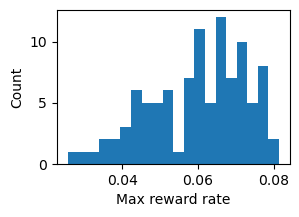

In [20]:
for i in range(5):
    sub_rates = rates[i * 20 : (i + 1) * 20]
    print(np.mean(sub_rates), np.std(sub_rates))

fig, axs = plt.subplots(1, 1, figsize=(3, 2))
axs.hist(rates, bins=20)
axs.set_xlabel('Max reward rate')
axs.set_ylabel('Count')
